##Fine-tuning y comparación de ConvNeXt Tiny y ViT Base para la clasificación de enfermedades en hojas de plantas usando PlantVillage.

#Entregable N°2

#20220540 Regalado Reyes, Renzo Joaquin

#20220231 Velásquez Paredes, Ramón Antonio

#20221953 Olivares Cornejo, Marcelo Daniel

#20192506 Guzman Vega, Shanti Jeremy


**Celda 1 — Instalación de librerías**

En esta sección se instala y prepara el entorno de trabajo necesario para ejecutar el pipeline de fine-tuning. De acuerdo con el entregable, el proyecto utiliza PyTorch, Hugging Face Transformers, Hugging Face Datasets, Evaluate y herramientas auxiliares para entrenar y evaluar modelos de clasificación de imágenes sobre PlantVillage.

Estas dependencias permiten cargar el dataset, aplicar preprocesamiento de imágenes, definir el modelo ConvNeXt Tiny preentrenado, entrenarlo con `Trainer` y calcular métricas de evaluación.

In [2]:
# Instalación de librerías necesarias para el proyecto.
# Se instala todo en una sola celda para evitar redundancias.

!pip install -q transformers datasets evaluate accelerate huggingface_hub fsspec scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.3 MB/s eta 0:00:00


In [1]:
from huggingface_hub import notebook_login

notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [3]:
from huggingface_hub import whoami

whoami()

{'type': 'user',
 'id': '6a31e85a1b240cf77619dd85',
 'name': 'Antonio27ve',
 'fullname': 'Velásquez',
 'isPro': False,
 'avatarUrl': 'https://cdn-avatars.huggingface.co/v1/production/uploads/noauth/pvnSx5RDt8SS4iJgQ1cRz.jpeg',
 'orgs': [],
 'auth': {'type': 'access_token',
  'accessToken': {'displayName': 'plantvillage-ta-equipo07',
   'role': 'fineGrained',
   'createdAt': '2026-06-17T00:25:24.184Z',
   'fineGrained': {'canReadGatedRepos': False,
    'global': [],
    'scoped': [{'entity': {'_id': '6a31e85a1b240cf77619dd85',
       'type': 'user',
       'name': 'Antonio27ve'},
      'permissions': ['repo.access.read',
       'repo.content.read',
       'repo.write']}]}}}}

**Celda 2 — Importaciones, semilla y entorno**

In [4]:
# Importaciones principales del proyecto.

import os
import zipfile
import random
import numpy as np
import matplotlib.pyplot as plt
import torch

from huggingface_hub import hf_hub_download
from datasets import Dataset, DatasetDict, Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

import evaluate

from torchvision.transforms import (
    Compose,
    Normalize,
    RandomHorizontalFlip,
    RandomRotation,
    ColorJitter,
    RandomResizedCrop,
    Resize,
    CenterCrop,
    ToTensor,
)

from transformers import (
    AutoImageProcessor,
    AutoModelForImageClassification,
    TrainingArguments,
    Trainer,
    set_seed,
)

# Fijamos semilla para que los resultados sean reproducibles.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

set_seed(SEED)

# Mostramos información del entorno de ejecución.
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo disponible: {device}")

if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("Versión de CUDA en PyTorch:", torch.version.cuda)

print("Versión de PyTorch:", torch.__version__)

Dispositivo disponible: cuda
GPU: Tesla T4
Versión de CUDA en PyTorch: 12.8
Versión de PyTorch: 2.11.0+cu128


**Celda 3 — Descarga y construcción del dataset PlantVillage**

Esta sección corresponde a la parte del entregable donde se define PlantVillage como dataset principal del proyecto. Se descarga la versión publicada en Hugging Face (`mohanty/PlantVillage`) y se utilizan los splits oficiales de la partición color: `color_train.txt` para entrenamiento y `color_test.txt` para evaluación.

El código construye un `DatasetDict` con dos particiones: `train` y `test`. Además de la imagen, se almacenan atributos útiles para el análisis posterior, como la etiqueta de clase, el cultivo, la enfermedad y el identificador de hoja física. Esto concuerda con la descripción del dataset en el entregable, donde se señala que PlantVillage contiene imágenes de hojas sanas y enfermas organizadas por cultivo y enfermedad.

data.zip:   0%|          | 0.00/2.18G [00:00<?, ?B/s]

color_train.txt:   0%|          | 0.00/4.15M [00:00<?, ?B/s]

color_test.txt:   0%|          | 0.00/1.02M [00:00<?, ?B/s]

Datos extraídos en: /content/plantvillage_data
¿Existe la carpeta raw?: True
DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'crop', 'disease', 'leaf_id'],
        num_rows: 43596
    })
    test: Dataset({
        features: ['image', 'label', 'crop', 'disease', 'leaf_id'],
        num_rows: 10709
    })
})
Ejemplo de etiqueta: Raspberry___healthy


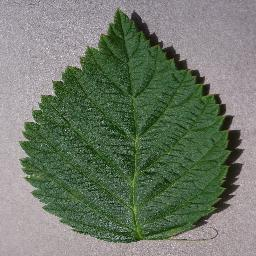

In [5]:
# Descargamos el dataset PlantVillage desde Hugging Face.
# Usaremos los archivos oficiales de entrenamiento y prueba.

repo_id = "mohanty/PlantVillage"

data_zip = hf_hub_download(
    repo_id=repo_id,
    repo_type="dataset",
    filename="data.zip"
)

train_txt = hf_hub_download(
    repo_id=repo_id,
    repo_type="dataset",
    filename="splits/color_train.txt"
)

test_txt = hf_hub_download(
    repo_id=repo_id,
    repo_type="dataset",
    filename="splits/color_test.txt"
)

# Definimos la carpeta donde se extraerán los datos.
extract_dir = "/content/plantvillage_data"
raw_dir = os.path.join(extract_dir, "raw")

os.makedirs(extract_dir, exist_ok=True)

# Extraemos el archivo solo si todavía no existe.
if not os.path.exists(raw_dir):
    with zipfile.ZipFile(data_zip, "r") as zf:
        zf.extractall(extract_dir)

print("Datos extraídos en:", extract_dir)
print("¿Existe la carpeta raw?:", os.path.exists(raw_dir))


# Función para construir un split del dataset a partir de los txt oficiales.
def build_split(txt_path, root_dir):
    with open(txt_path, "r", encoding="utf-8") as f:
        rel_paths = [line.strip() for line in f if line.strip()]

    abs_paths = [os.path.join(root_dir, p) for p in rel_paths]

    # La etiqueta de clase se obtiene del nombre de la carpeta.
    labels_texto = [p.split("/")[2] for p in rel_paths]

    # Atributos adicionales útiles para análisis posteriores.
    crops = [lbl.split("___")[0] for lbl in labels_texto]
    diseases = [lbl.split("___", 1)[1] for lbl in labels_texto]
    leaf_ids = [os.path.basename(p).split("___")[0] for p in rel_paths]

    ds = Dataset.from_dict(
        {
            "image": abs_paths,
            "label": labels_texto,
            "crop": crops,
            "disease": diseases,
            "leaf_id": leaf_ids,
        }
    )

    # Convertimos la columna image al tipo Image de datasets.
    return ds.cast_column("image", Image())


# Construimos el dataset original con train y test oficiales.
dataset_original = DatasetDict(
    {
        "train": build_split(train_txt, extract_dir),
        "test": build_split(test_txt, extract_dir),
    }
)

print(dataset_original)
print("Ejemplo de etiqueta:", dataset_original["train"][0]["label"])
display(dataset_original["train"][0]["image"])

**Celda 4 — Codificación de etiquetas y creación del conjunto de validación**

En esta sección se transforman las etiquetas originales del dataset, que están en formato texto, a identificadores numéricos. Esto es necesario porque el modelo de clasificación trabaja internamente con índices enteros para calcular la función de pérdida y comparar las predicciones con las clases reales.

También se crean los diccionarios `label2id` e `id2label`, que permiten mapear cada clase de PlantVillage a un número y recuperar posteriormente el nombre de la clase predicha. Este paso es clave porque el problema planteado en el entregable es una clasificación multiclase de enfermedades foliares.

In [6]:
# Creamos diccionarios para convertir etiquetas de texto a enteros.
# Esto es necesario para entrenar el modelo.

labels_ordenadas = sorted(set(dataset_original["train"]["label"]))
label2id = {label: idx for idx, label in enumerate(labels_ordenadas)}
id2label = {idx: label for label, idx in label2id.items()}

print("Número de clases:", len(labels_ordenadas))
print("Primera clase:", labels_ordenadas[0])


# Función para agregar la columna numérica "labels".
def encode_labels(example):
    example["labels"] = label2id[example["label"]]
    return example


# Aplicamos la codificación al dataset completo.
dataset_original = dataset_original.map(encode_labels)


# IMPORTANTE:
# No usaremos el conjunto de prueba para seleccionar el mejor modelo.
# Por eso, separamos el train oficial en train y validation.
indices = np.arange(len(dataset_original["train"]))

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.10,                         # 10% para validación
    random_state=SEED,
    stratify=dataset_original["train"]["labels"]  # Split estratificado
)

dataset = DatasetDict(
    {
        "train": dataset_original["train"].select(train_idx.tolist()),
        "validation": dataset_original["train"].select(val_idx.tolist()),
        "test": dataset_original["test"],   # El test oficial queda intacto
    }
)

print(dataset)
print("Tamaño train:", len(dataset["train"]))
print("Tamaño validation:", len(dataset["validation"]))
print("Tamaño test:", len(dataset["test"]))

Número de clases: 38
Primera clase: Apple___Apple_scab


Map:   0%|          | 0/43596 [00:00<?, ? examples/s]

Map:   0%|          | 0/10709 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'crop', 'disease', 'leaf_id', 'labels'],
        num_rows: 39236
    })
    validation: Dataset({
        features: ['image', 'label', 'crop', 'disease', 'leaf_id', 'labels'],
        num_rows: 4360
    })
    test: Dataset({
        features: ['image', 'label', 'crop', 'disease', 'leaf_id', 'labels'],
        num_rows: 10709
    })
})
Tamaño train: 39236
Tamaño validation: 4360
Tamaño test: 10709


**Celda 5 — Selección del modelo y transformaciones de imagen**

Esta sección implementa el preprocesamiento descrito en el entregable. Las imágenes se adaptan al formato esperado por `facebook/convnext-tiny-224`, que trabaja con entradas de 224 × 224 píxeles.

Para entrenamiento se utiliza `RandomResizedCrop`, lo que introduce variabilidad y funciona como aumento de datos. Para evaluación se usan transformaciones deterministas mediante `Resize` y `CenterCrop`, con el objetivo de medir el desempeño del modelo de forma estable.

Además, se aplica la normalización propia del procesador asociado a ConvNeXt Tiny, de modo que las imágenes tengan la misma escala estadística que las imágenes usadas durante el preentrenamiento del modelo.



In [7]:
# Elegimos el checkpoint base.
# Primero trabajaremos con ConvNeXt.
# Más adelante, para ViT, solo cambiaremos esta variable.

checkpoint = "facebook/convnext-tiny-224"

# Cargamos el procesador asociado al modelo.
image_processor = AutoImageProcessor.from_pretrained(checkpoint)

# Algunos modelos usan "shortest_edge" y otros "height/width".
if "shortest_edge" in image_processor.size:
    img_size = image_processor.size["shortest_edge"]
else:
    img_size = image_processor.size["height"]

print("Resolución esperada por el modelo:", img_size)

# Normalización usando la media y desviación estándar del modelo preentrenado.
normalize = Normalize(
    mean=image_processor.image_mean,
    std=image_processor.image_std
)

# Transformaciones para entrenamiento.
# Aquí sí usamos aumentos de datos.
train_transforms = Compose([
    RandomResizedCrop((img_size, img_size)),
    RandomHorizontalFlip(p=0.5),
    RandomRotation(degrees=10),
    ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    ToTensor(),
    normalize,
])

# Transformaciones para validación y prueba.
# Aquí NO usamos aumentos aleatorios.
eval_transforms = Compose([
    Resize((img_size, img_size)),
    CenterCrop((img_size, img_size)),
    ToTensor(),
    normalize,
])


# Función de preprocesamiento para train.
def preprocess_train(example_batch):
    pixel_values = [train_transforms(img.convert("RGB")) for img in example_batch["image"]]
    return {
        "pixel_values": pixel_values,
        "labels": example_batch["labels"],
    }


# Función de preprocesamiento para validation y test.
def preprocess_eval(example_batch):
    pixel_values = [eval_transforms(img.convert("RGB")) for img in example_batch["image"]]
    return {
        "pixel_values": pixel_values,
        "labels": example_batch["labels"],
    }


# Aplicamos las transformaciones a cada split.
train_ds = dataset["train"].with_transform(preprocess_train)
val_ds = dataset["validation"].with_transform(preprocess_eval)
test_ds = dataset["test"].with_transform(preprocess_eval)

preprocessor_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

Resolución esperada por el modelo: 224


**Celda 6 — Verificación rápida de una muestra**

In [8]:
# Verificamos que una muestra tenga el formato correcto.

sample = train_ds[0]

print("Claves de la muestra:", sample.keys())
print("Tipo de labels:", type(sample["labels"]))
print("Valor de labels:", sample["labels"])
print("Forma de pixel_values:", sample["pixel_values"].shape)
print("Clase textual:", id2label[sample["labels"]])

Claves de la muestra: dict_keys(['pixel_values', 'labels'])
Tipo de labels: <class 'int'>
Valor de labels: 24
Forma de pixel_values: torch.Size([3, 224, 224])
Clase textual: Soybean___healthy


**Celda 7 — Métricas y función de collate**

In [9]:
# Cargamos las métricas que se usarán durante la evaluación.

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")


# Esta función calcula accuracy y macro-F1.
# Macro-F1 es importante porque promedia el rendimiento entre clases.
def compute_metrics(eval_pred):
    logits, labels_reales = eval_pred
    predicciones = np.argmax(logits, axis=1)

    accuracy = accuracy_metric.compute(
        predictions=predicciones,
        references=labels_reales
    )["accuracy"]

    macro_f1 = f1_metric.compute(
        predictions=predicciones,
        references=labels_reales,
        average="macro"
    )["f1"]

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1
    }


# Función para juntar los ejemplos en batches.
# Esta versión es clara y evita problemas con columnas extra del dataset.
def collate_fn(batch):
    pixel_values = torch.stack([example["pixel_values"] for example in batch])
    labels = torch.tensor([example["labels"] for example in batch])

    return {
        "pixel_values": pixel_values,
        "labels": labels
    }

**Celda 8 — Carga del modelo**

In [10]:
# Cargamos el modelo de clasificación de imágenes.
# Se ajusta automáticamente al número de clases de PlantVillage.

model = AutoModelForImageClassification.from_pretrained(
    checkpoint,
    num_labels=len(labels_ordenadas),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

print("Modelo cargado correctamente.")
print("Número de clases configuradas:", model.config.num_labels)

config.json:   0%|          | 0.00/69.6k [00:00<?, ?B/s]

[transformers] You passed `num_labels=38` which is incompatible to the `id2label` map of length `1000`.


pytorch_model.bin:   0%|          | 0.00/114M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/182 [00:00<?, ?it/s]

[transformers] ConvNextForImageClassification LOAD REPORT from: facebook/convnext-tiny-224
Key               | Status   |                                                                                           
------------------+----------+-------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([38, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([38])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Modelo cargado correctamente.
Número de clases configuradas: 38


**Celda 9 — Argumentos de entrenamiento**

In [11]:
# Definimos los argumentos del entrenamiento.
# Aquí corregimos el problema metodológico del notebook original:
# el mejor modelo se escogerá usando VALIDATION, no TEST.

training_args = TrainingArguments(
    output_dir="/content/convnext_plantvillage",
    remove_unused_columns=False,

    # Evaluación y guardado por época.
    eval_strategy="epoch",
    save_strategy="epoch",

    # Hiperparámetros principales.
    learning_rate=5e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    warmup_ratio=0.10,
    weight_decay=0.01,

    # Logging.
    logging_strategy="steps",
    logging_steps=50,

    # Selección del mejor modelo.
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    # Control de checkpoints.
    save_total_limit=2,

    # Uso de precisión mixta si hay GPU.
    fp16=torch.cuda.is_available(),

    # Sin reportes a plataformas externas.
    report_to="none",

    # Reproducibilidad.
    seed=SEED
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


**Celda 10 — Entrenamiento con validation**

In [12]:
# Creamos el Trainer.
# Observa que eval_dataset ahora es val_ds y no test_ds.

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=collate_fn,
    processing_class=image_processor,
    compute_metrics=compute_metrics
)

# Entrenamos el modelo.
train_output = trainer.train()

print("Entrenamiento finalizado.")
print(train_output)

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.148663,0.083930,0.980275,0.968210
2,0.067525,0.026676,0.992202,0.989604
3,0.032829,0.015509,0.995642,0.993949


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Entrenamiento finalizado.
TrainOutput(global_step=7359, training_loss=0.3845202430529931, metrics={'train_runtime': 1328.5718, 'train_samples_per_second': 88.597, 'train_steps_per_second': 5.539, 'total_flos': 2.9606671540260864e+18, 'train_loss': 0.3845202430529931, 'epoch': 3.0})


**Celda 11 — Evaluación en validation y en test**

In [13]:
# Primero evaluamos en validation.
# Esto sirve para revisar el rendimiento durante el desarrollo.

resultado_validacion = trainer.evaluate(eval_dataset=val_ds)

print("Resultados en validation:")
print(resultado_validacion)


# Luego evaluamos en test.
# Esta evaluación sí es final y no debe usarse para ajustar hiperparámetros.
resultado_prueba = trainer.evaluate(eval_dataset=test_ds)

print("\nResultados finales en test:")
print(resultado_prueba)

Training Loss,Validation Loss,Epoch,Accuracy,Macro F1
0.032829,0.015509,3,0.995642,0.993949


Resultados en validation:
{'eval_loss': 0.015508763492107391, 'eval_accuracy': 0.9956422018348624, 'eval_macro_f1': 0.9939493238674085}


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1
0.032829,0.024720,3,0.992623,0.990560



Resultados finales en test:
{'eval_loss': 0.024720489978790283, 'eval_accuracy': 0.9926230273601644, 'eval_macro_f1': 0.9905599822747131}


**Celda 12 — Predicciones finales, classification report y matriz de confusión**

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     1.0000    0.9921    0.9960       127
                                 Apple___Black_rot     1.0000    1.0000    1.0000       146
                          Apple___Cedar_apple_rust     1.0000    1.0000    1.0000        52
                                   Apple___healthy     0.9964    0.9790    0.9877       286
                               Blueberry___healthy     0.9848    1.0000    0.9923       324
          Cherry_(including_sour)___Powdery_mildew     1.0000    1.0000    1.0000       219
                 Cherry_(including_sour)___healthy     0.9840    1.0000    0.9919       123
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.9524    0.9346    0.9434       107
                       Corn_(maize)___Common_rust_     1.0000    0.9954    0.9977       217
               Corn_(maize)___Northern_Leaf_Blight     0.9641    0.9773    0.97

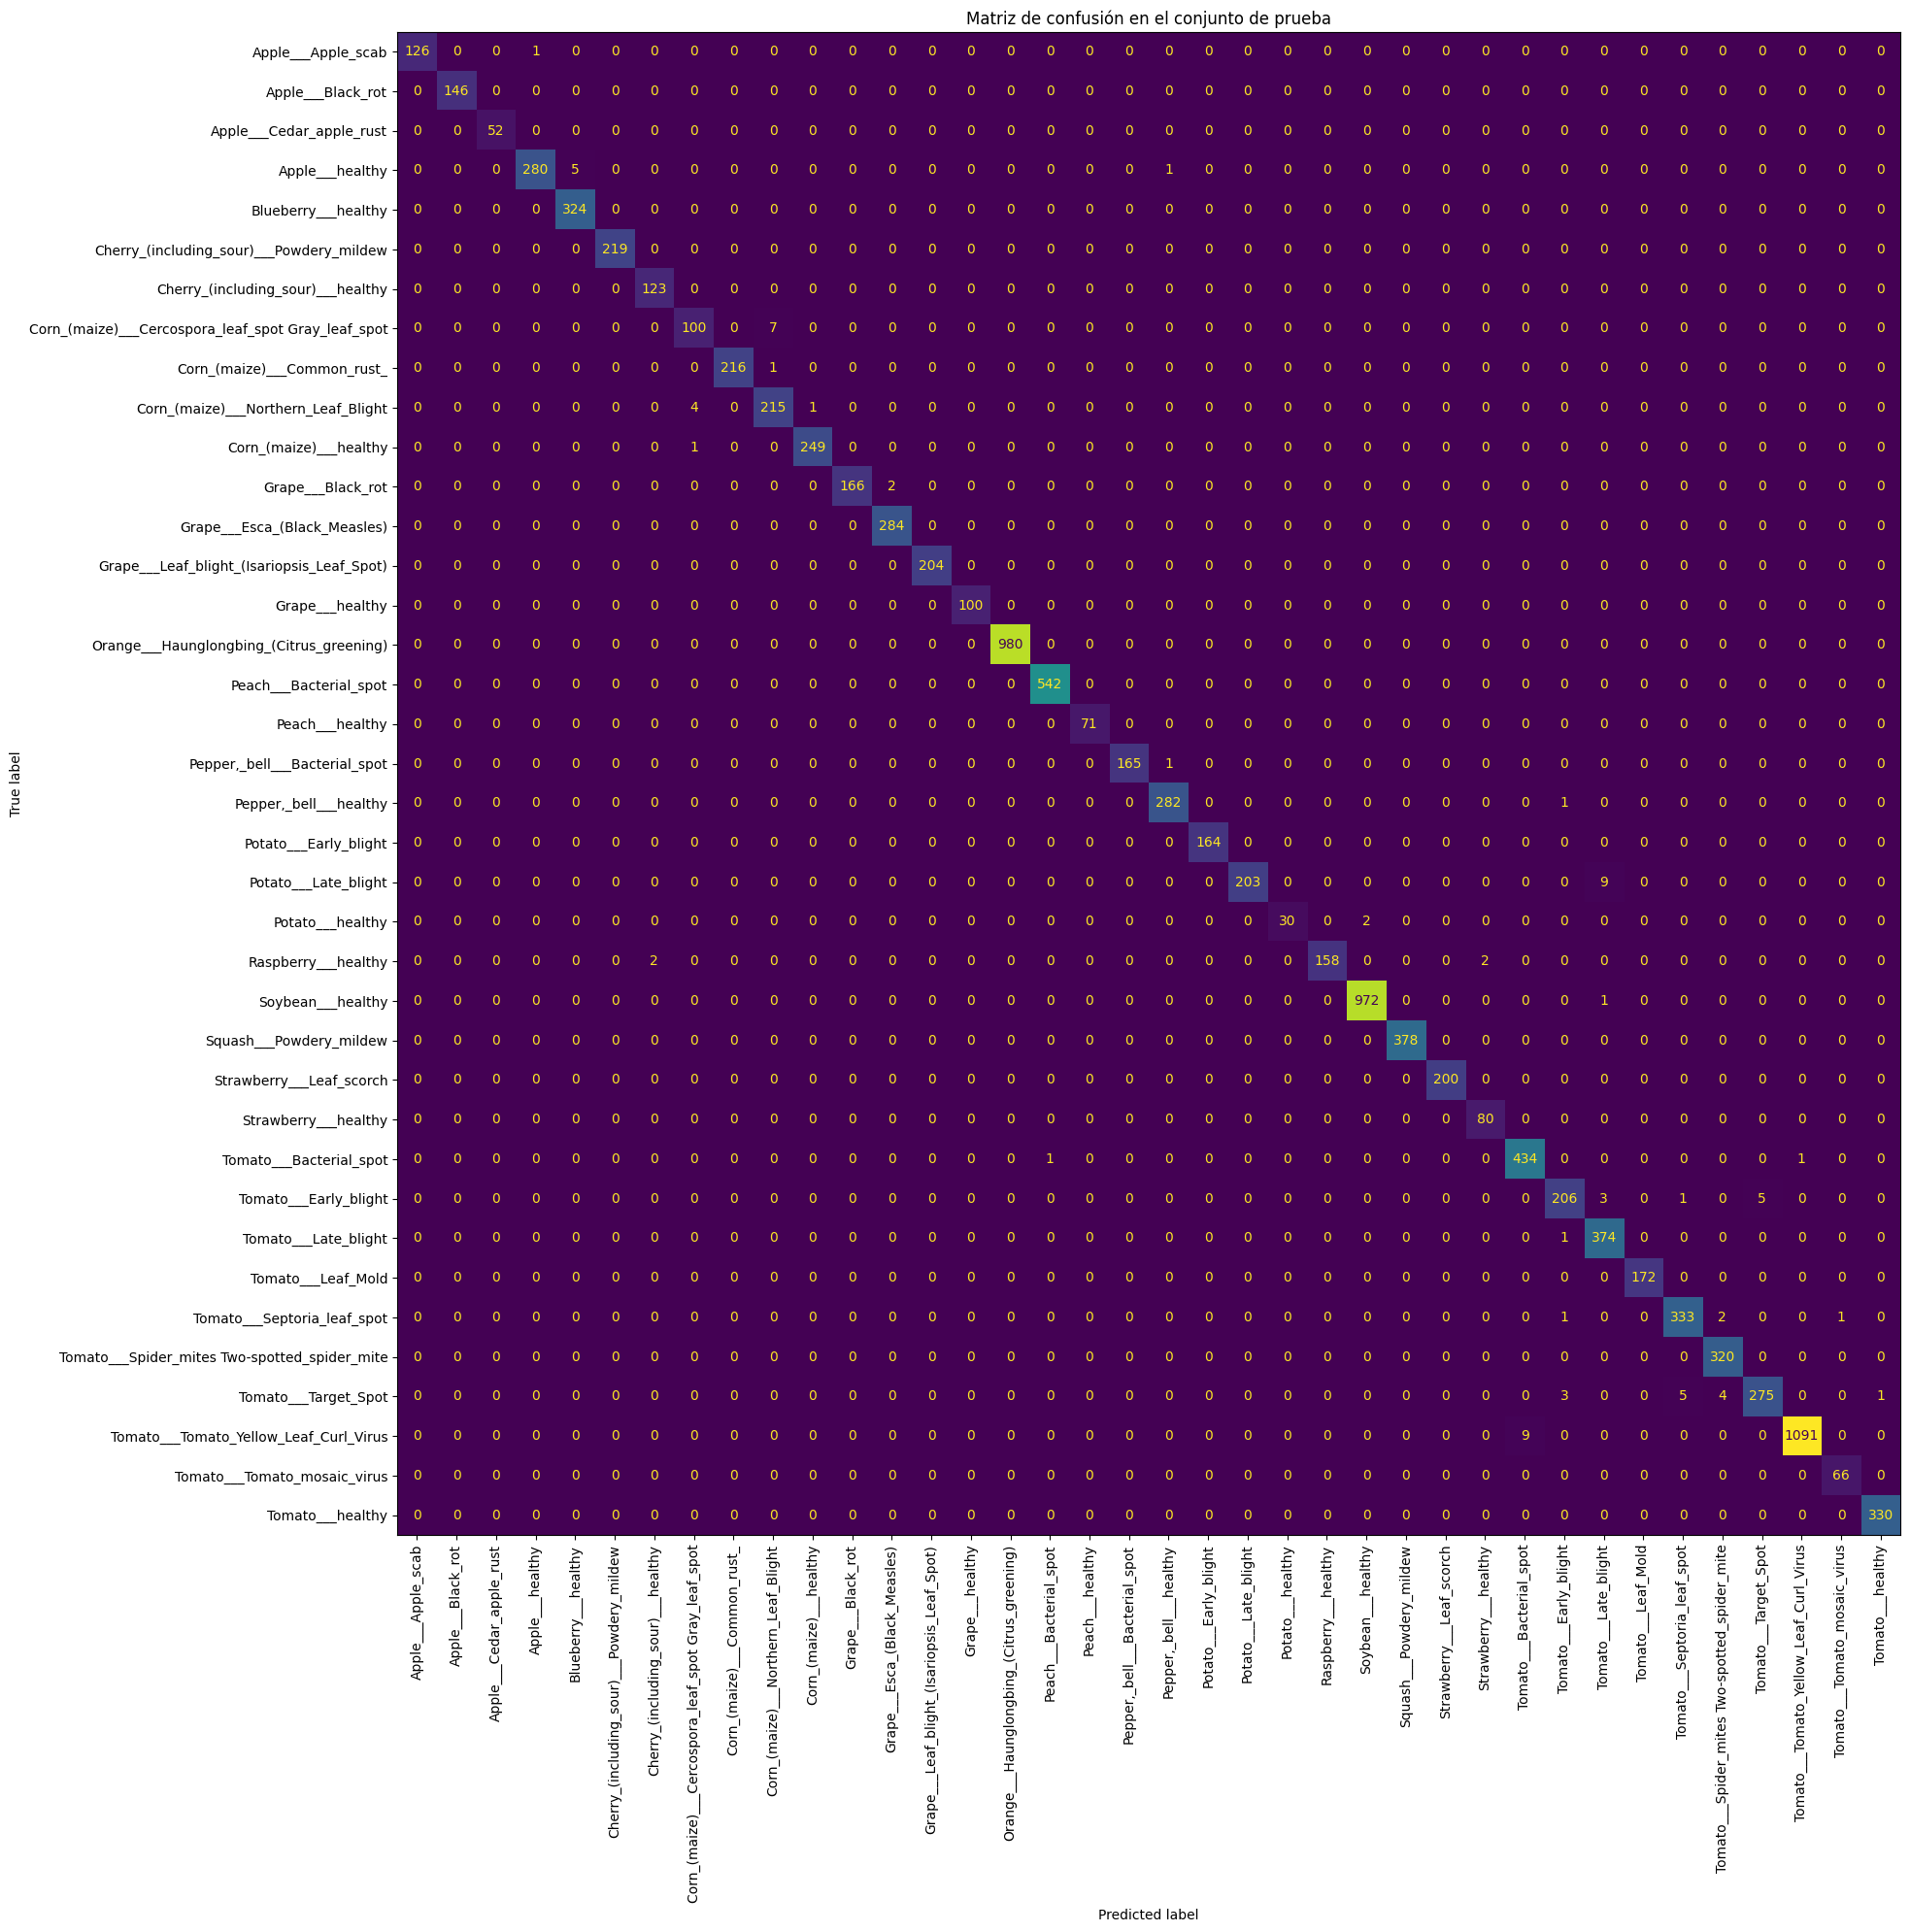

In [14]:
# Generamos predicciones sobre el conjunto de prueba.
pred_test = trainer.predict(test_ds)

# Etiquetas reales.
y_true = pred_test.label_ids

# Etiquetas predichas.
y_pred = np.argmax(pred_test.predictions, axis=1)

# Reporte de clasificación por clase.
print(classification_report(
    y_true,
    y_pred,
    target_names=labels_ordenadas,
    digits=4
))

# Matriz de confusión.
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(20, 20))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_ordenadas)
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)

plt.title("Matriz de confusión en el conjunto de prueba")
plt.tight_layout()
plt.show()

**Celda 13 — Curvas de entrenamiento y validación**

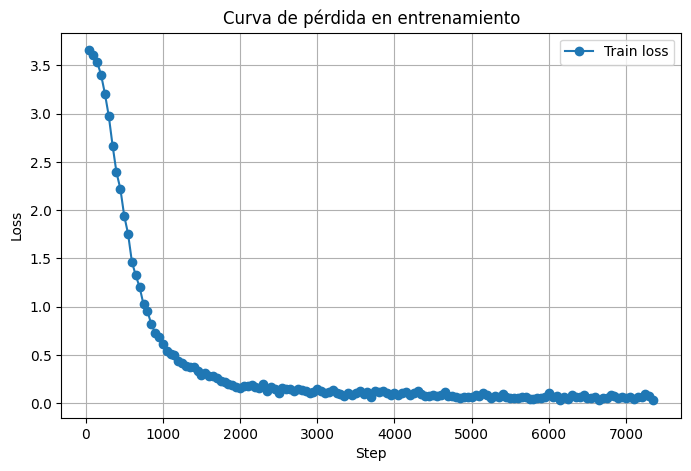

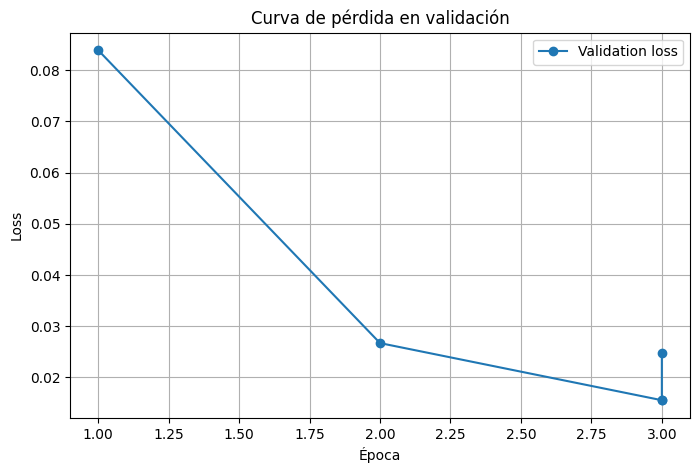

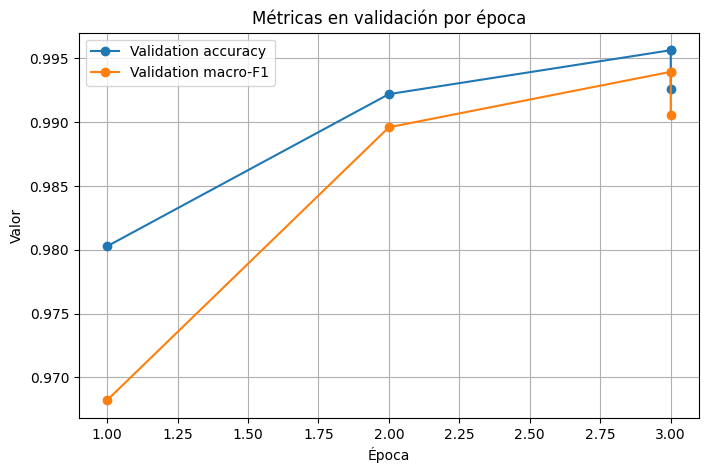

In [15]:
# Extraemos el historial del entrenamiento para graficar curvas.
historial = trainer.state.log_history

train_loss_steps = []
train_loss_values = []

eval_epochs = []
eval_loss_values = []
eval_accuracy_values = []
eval_f1_values = []

for registro in historial:
    # Pérdida de entrenamiento.
    if "loss" in registro and "epoch" in registro:
        train_loss_steps.append(registro.get("step"))
        train_loss_values.append(registro.get("loss"))

    # Métricas de validación.
    if "eval_loss" in registro and "epoch" in registro:
        eval_epochs.append(registro.get("epoch"))
        eval_loss_values.append(registro.get("eval_loss"))
        eval_accuracy_values.append(registro.get("eval_accuracy"))
        eval_f1_values.append(registro.get("eval_macro_f1"))


# Curva de pérdida de entrenamiento.
plt.figure(figsize=(8, 5))
plt.plot(train_loss_steps, train_loss_values, marker="o", label="Train loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Curva de pérdida en entrenamiento")
plt.legend()
plt.grid(True)
plt.show()


# Curva de pérdida de validación.
plt.figure(figsize=(8, 5))
plt.plot(eval_epochs, eval_loss_values, marker="o", label="Validation loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Curva de pérdida en validación")
plt.legend()
plt.grid(True)
plt.show()


# Curvas de accuracy y macro-F1 en validación.
plt.figure(figsize=(8, 5))
plt.plot(eval_epochs, eval_accuracy_values, marker="o", label="Validation accuracy")
plt.plot(eval_epochs, eval_f1_values, marker="o", label="Validation macro-F1")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.title("Métricas en validación por época")
plt.legend()
plt.grid(True)
plt.show()

**Celda 14 — Predicción de una imagen individual**

Etiqueta real: Tomato___Tomato_mosaic_virus
Etiqueta predicha: Tomato___Tomato_mosaic_virus


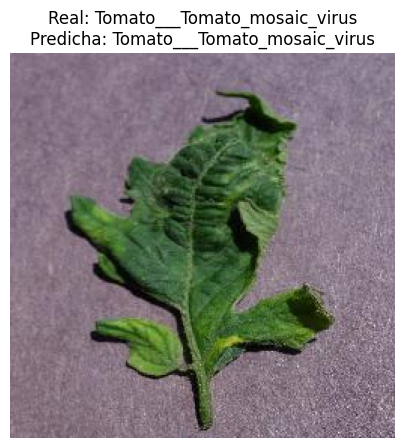

In [19]:
# Probamos una predicción sobre una imagen del conjunto de prueba.

indice = 1000

imagen = dataset["test"][indice]["image"]
label_real = dataset["test"][indice]["label"]

# Preprocesamos la imagen para inferencia.
tensor = eval_transforms(imagen.convert("RGB")).unsqueeze(0).to(model.device)

# Desactivamos gradientes porque solo vamos a inferir.
with torch.no_grad():
    outputs = model(pixel_values=tensor)
    pred_id = outputs.logits.argmax(dim=1).item()

label_predicha = id2label[pred_id]

print("Etiqueta real:", label_real)
print("Etiqueta predicha:", label_predicha)

plt.figure(figsize=(5, 5))
plt.imshow(imagen)
plt.title(f"Real: {label_real}\nPredicha: {label_predicha}")
plt.axis("off")
plt.show()

##Evaluación de Resultados

Los resultados obtenidos muestran que el modelo ConvNeXt Tiny logró un desempeño muy alto en la clasificación de enfermedades foliares del dataset PlantVillage. Durante el entrenamiento, la pérdida disminuyó progresivamente y las métricas de validación aumentaron hasta alcanzar un accuracy de 99.56 % y un macro-F1 de 99.39 %, lo que evidencia una adecuada capacidad de aprendizaje. En el conjunto de prueba final, el modelo obtuvo un accuracy de 99.26 % y un macro-F1 de 99.06 %, valores muy cercanos a los de validación, por lo que se puede afirmar que el modelo generaliza correctamente a datos no vistos.

A partir del reporte de clasificación, se observa que la mayoría de clases presentan valores de precisión, recall y F1-score cercanos a 1. Las principales dificultades aparecen en clases como Corn Cercospora Gray Leaf Spot, Tomato Early Blight, Tomato Target Spot y Corn Northern Leaf Blight, probablemente debido a la similitud visual entre síntomas foliares. En general, la matriz de confusión confirma que la mayor parte de predicciones se concentra en la diagonal principal, lo cual indica una alta correspondencia entre etiquetas reales y predichas.

Como conclusión, el modelo entrenado presenta un rendimiento sólido para clasificación multiclase de enfermedades de plantas. Sin embargo, debe considerarse que PlantVillage contiene imágenes relativamente controladas, por lo que para una aplicación real en campo sería recomendable validar el modelo con imágenes tomadas en condiciones variables de iluminación, fondo, orientación y calidad de captura.

In [17]:
from huggingface_hub import create_repo

repo_id = "Antonio27ve/convnext-plantvillage-equipo07"

create_repo(repo_id, exist_ok=True)

trainer.model.push_to_hub(repo_id)
image_processor.push_to_hub(repo_id)

print("Modelo subido correctamente a:", repo_id)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...qqci0a8/model.safetensors:   0%|          |  551kB /  111MB            

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

Modelo subido correctamente a: Antonio27ve/convnext-plantvillage-equipo07
